# Cost function optimization landscape

Pennylane tutorial:
https://pennylane.ai/qml/demos/tutorial_local_cost_functions

## Analytic expression of the global loss function

We precompute the global loss functon under the circuit Ansatz of one layer $Ry(\theta_1)$ and one layer $Rx(\theta_2)$ with parameter $\theta_1, \theta_2\in[-\pi, \pi]$. We have the global loss function given by
\begin{align}C_G(\theta_1, \theta_2)&=1-\left(\cos^{2}\left(\frac{\theta_1}{2}\right)\cos^{2}\left(\frac{\theta_2}{2}\right) + \sin^{2}\left(\frac{\theta_1}{2}\right)\sin^{2}\left(\frac{\theta_2}{2}\right)\right)^{n}\\ &= 1 - \left(\frac{1 + \cos\theta_{1} \cos\theta_{2}}{2} \right)^{n}\end{align}

## Change the cost function to our tilted loss

Here we plot the 2D optimization landscape in a way similar to the tutorial, except for the change of loss function.

Since we focus on the regime when tilting parameter is negative, we define the loss function by 
$$ \mathcal{L}_\gamma(O,\rho(\bm{\theta})) := - \frac{1}{\gamma} \log \text{tr} \!\left( e^{- \gamma O} \rho(\bm{\theta}) \right),$$
so as to make gamma positive. If we consider the 2D optimization landscape with the same circuit Ansatz and, we have the cost function given by
$$\mathcal{L}_\gamma(O_G,\rho(\bm{\theta}))= - \frac{1}{\gamma}  \log\left(1 + (e^{-\gamma}-1)\left[1 - \left(\frac{1 + \cos\theta_{1} \cos\theta_{2}}{2} \right)^{n} \right]\right).$$
Then the optimization landscape is plotted as below.

C:\Users\fff\AppData\Local\Temp\ipykernel_25944\2786616407.py:40: RuntimeWarning: divide by zero encountered in log
  return -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * calculate_C_G(n_qubits, theta1, theta2))


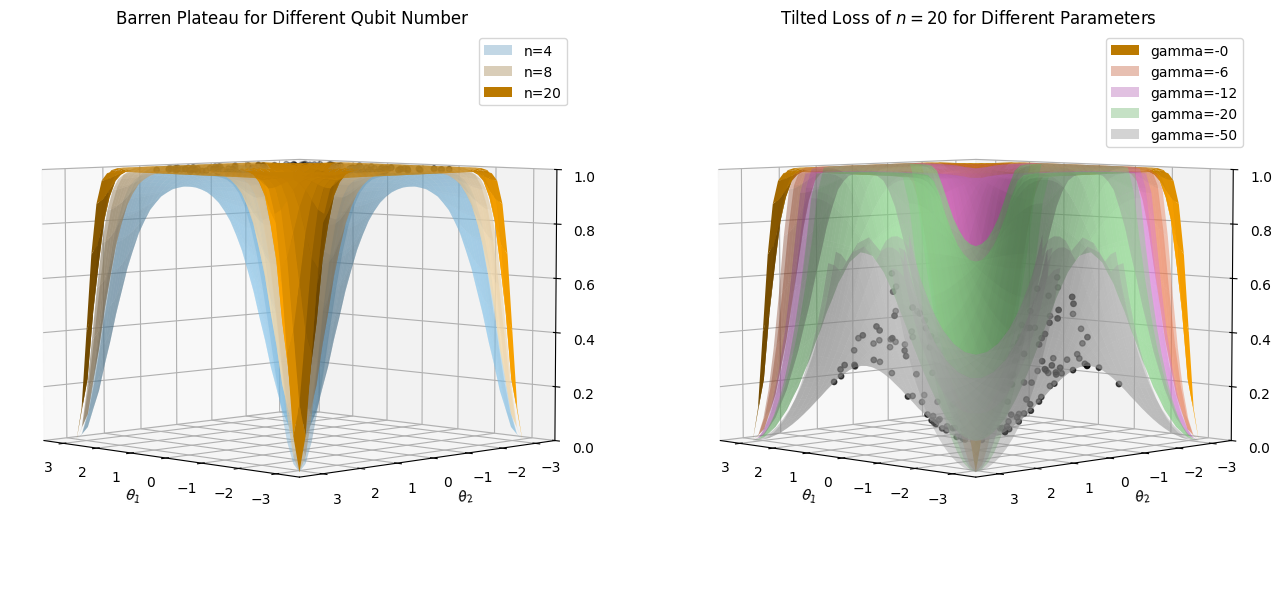

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

res = 40       # Resolution of the grid
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)

def calculate_C_G(n_qubits, theta1, theta2):
    """
    Calculates the value of C_G(theta1, theta2).

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).

    Returns:
    float or np.ndarray: The calculated value of C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    term = (1 + np.cos(theta1) * np.cos(theta2)) / 2
    return 1 - np.power(term, n_qubits)

def calculate_tilted_C_G(n_qubits, theta1, theta2, gamma):
    """
    Calculates the value of tilted loss function.

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).
    gamma (float or np.ndarray): tilting parameter.

    Returns:
    float or np.ndarray: The calculated value of tilted C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    return -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * calculate_C_G(n_qubits, theta1, theta2))


def calculate_loss(n_qubits, gamma=None, mode="Orginal"):
    if gamma == 0:
        mode = "Orginal"
    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            Z[i, j] = calculate_C_G(n_qubits, x[i], y[j]) if mode == 'Orginal' else calculate_tilted_C_G(n_qubits, x[i], y[j], gamma)
    return Z


# Calculate the original landscape with different qubits
Qubits = [4, 8, 20]
# Qubits = [10, 20]
# Qubits = [10]
Z_original = []
for q in Qubits:
    Z_original.append(calculate_loss(q))

# Calculate the tilted loss landscape with different gammas
Gammas = [0, 6, 12, 20, 50]
# Gammas = [10]
Z_tilted = []
n_qubits = 20
for gamma in Gammas:
    Z_tilted.append(calculate_loss(n_qubits, gamma, mode='Tilted'))

# Plotting
fig = plt.figure(figsize=(16, 16))


# Original Cost Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
colors_qubit = ['lightskyblue', 'moccasin', 'orange']
cmap_choices_qubit = [cm.coolwarm, 'viridis', 'plasma']
transparency_qubit = [0.4, 0.6, 1]
for i in range(len(Qubits)):
    q = Qubits[i]
    Z = Z_original[i]
    surf = ax1.plot_surface(X, Y, Z, color=colors_qubit[i], alpha=transparency_qubit[i], label='n='+str(q), zorder=1)

x_samples = np.random.uniform(-0.7*np.pi, 0.7*np.pi, 200) # Example data
y_samples = np.random.uniform(-0.7*np.pi, 0.7*np.pi, 200) # Example data
z_points = calculate_C_G(n_qubits, x_samples, y_samples)
ax1.scatter(x_samples, y_samples, z_points, color='black', s=15, zorder=100)

ax1.set_title(f"Barren Plateau for Different Qubit Number")
ax1.set_xlabel('$\\theta_1$')
ax1.set_ylabel('$\\theta_2$')
ax1.legend(loc='best')
ax1.set_zlim(0, 1)
ax1.view_init(elev=5, azim=135)


# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
colors_gamma = ['orange', 'coral', 'violet', 'lightgreen', 'silver']
cmap_choices_gamma = ['plasma', cm.coolwarm, 'viridis']
transparency_gamma = [1, 0.4, 0.4, 0.4, 0.4]
for i in range(len(Gammas)):
    gamma = Gammas[i]
    Z = Z_tilted[i]
    surf = ax2.plot_surface(X, Y, Z, color=colors_gamma[i], alpha=transparency_gamma[i], label='gamma=-'+str(gamma), zorder=1)

x_samples = np.random.uniform(-0.7*np.pi, 0.7*np.pi, 200) # Example data
y_samples = np.random.uniform(-0.7*np.pi, 0.7*np.pi, 200) # Example data
z_points = -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * calculate_C_G(n_qubits, x_samples, y_samples))

ax2.scatter(x_samples, y_samples, z_points, color='black', s=15, zorder=100)
ax2.set_title(f"Tilted Loss of $n=20$ for Different Parameters")
ax2.set_xlabel('$\\theta_1$')
ax2.set_ylabel('$\\theta_2$')
ax2.legend(loc='best')
ax2.set_zlim(0, 1)
ax2.view_init(elev=5, azim=135)

# plt.tight_layout()
plt.show()



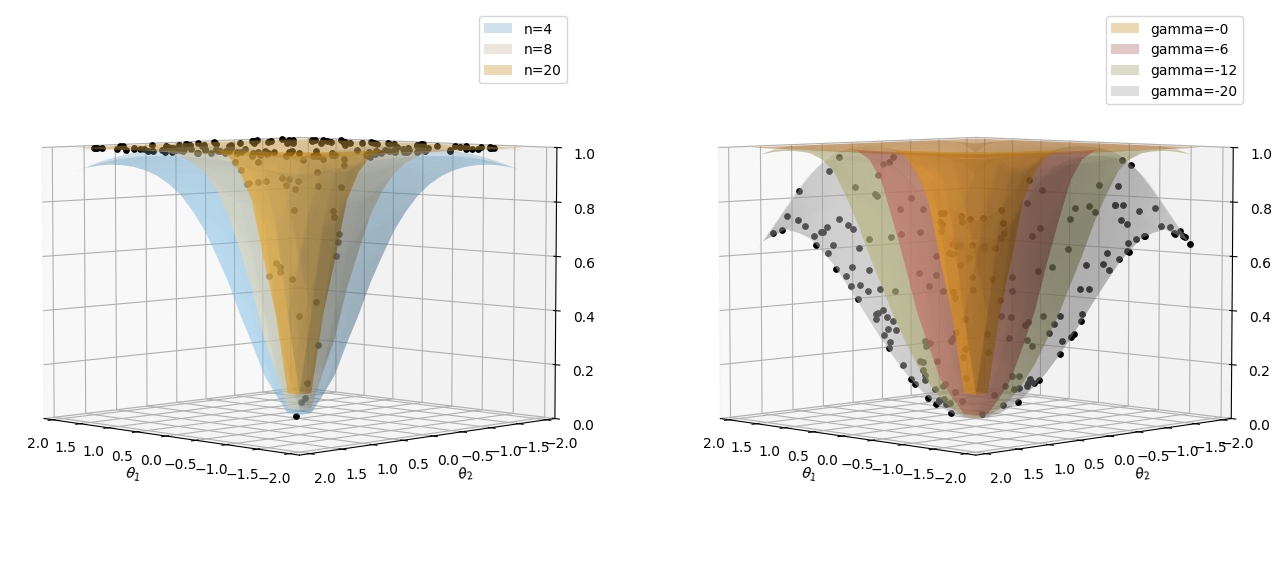

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

res = 20       # Resolution of the grid
x = np.linspace(-0.6*np.pi, 0.6*np.pi, res)
y = np.linspace(-0.6*np.pi, 0.6*np.pi, res)
X, Y = np.meshgrid(x, y)

def calculate_C_G(n_qubits, theta1, theta2):
    """
    Calculates the value of C_G(theta1, theta2).

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).

    Returns:
    float or np.ndarray: The calculated value of C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    term = (1 + np.cos(theta1) * np.cos(theta2)) / 2
    return 1 - np.power(term, n_qubits)

def calculate_tilted_C_G(n_qubits, theta1, theta2, gamma):
    """
    Calculates the value of tilted loss function.

    Parameters:
    n_qubits (int or float): The exponent parameter n.
    theta1 (float or np.ndarray): The first angle parameter (theta_1).
    theta2 (float or np.ndarray): The second angle parameter (theta_2).
    gamma (float or np.ndarray): tilting parameter.

    Returns:
    float or np.ndarray: The calculated value of tilted C_G.
    """
    # Using the simplified expression: 1 - ((1 + cos(theta1) * cos(theta2)) / 2)^n
    return -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * calculate_C_G(n_qubits, theta1, theta2))


def calculate_loss(n_qubits, gamma=None, mode="Orginal"):
    if gamma == 0:
        mode = "Orginal"
    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            Z[i, j] = calculate_C_G(n_qubits, x[i], y[j]) if mode == 'Orginal' else calculate_tilted_C_G(n_qubits, x[i], y[j], gamma)
    return Z


# Calculate the original landscape with different qubits
Qubits = [4, 8, 20]
# Qubits = [10, 20]
# Qubits = [10]
Z_original = []
for q in Qubits:
    Z_original.append(calculate_loss(q))

# Calculate the tilted loss landscape with different gammas
Gammas = [0, 6, 12, 20]
# Gammas = [10]
Z_tilted = []
n_qubits = 20
for gamma in Gammas:
    Z_tilted.append(calculate_loss(n_qubits, gamma, mode='Tilted'))

# Plotting
fig = plt.figure(figsize=(16, 16))


# Original Cost Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
x_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
y_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
z_points = calculate_C_G(n_qubits, x_samples, y_samples)
ax1.scatter(x_samples, y_samples, z_points, color='black', depthshade=False, s=15, zorder=2.01)

colors_qubit = ['lightskyblue', 'moccasin', 'orange']
cmap_choices_qubit = [cm.coolwarm, 'viridis', 'plasma']
transparency_qubit = [0.3, 0.3, 0.3]
for i in range(len(Qubits)):
    q = Qubits[i]
    Z = Z_original[i]
    surf = ax1.plot_surface(X, Y, Z, color=colors_qubit[i], alpha=transparency_qubit[i], label='n='+str(q), zorder=1)

# ax1.set_title(f"Barren Plateau for Different Qubit Number")
ax1.set_xlabel('$\\theta_1$')
ax1.set_ylabel('$\\theta_2$')
ax1.legend(loc='best')
ax1.set_zlim(0, 1)
ax1.view_init(elev=5, azim=135)


# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
x_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
y_samples = np.random.uniform(-0.6*np.pi, 0.6*np.pi, 200) # Example data
z_points = calculate_tilted_C_G(n_qubits, x_samples, y_samples, gamma)
ax2.scatter(x_samples, y_samples, z_points, color='black', depthshade=False, s=15, zorder=2.01)

colors_gamma = ['orange', 'indianred', 'darkkhaki', 'silver']
cmap_choices_gamma = ['plasma', cm.coolwarm, 'viridis']
transparency_gamma = [0.3, 0.3, 0.3, 0.3]
for i in range(len(Gammas)):
    gamma = Gammas[i]
    Z = Z_tilted[i]
    surf = ax2.plot_surface(X, Y, Z, color=colors_gamma[i], alpha=transparency_gamma[i], label='gamma=-'+str(gamma), zorder=1)


# ax2.set_title(f"Tilted Loss of $n=20$ for Different Parameters")
ax2.set_xlabel('$\\theta_1$')
ax2.set_ylabel('$\\theta_2$')
ax2.legend(loc='best')
ax2.set_zlim(0, 1)
ax2.view_init(elev=5, azim=135)

# plt.tight_layout()
plt.show()



# Below are old codes

Here by focusing on the angles between [-pi/2, pi/2], we have

Generating Global Cost landscape (10 qubits)...
Generating Local Cost landscape (2 qubits)...


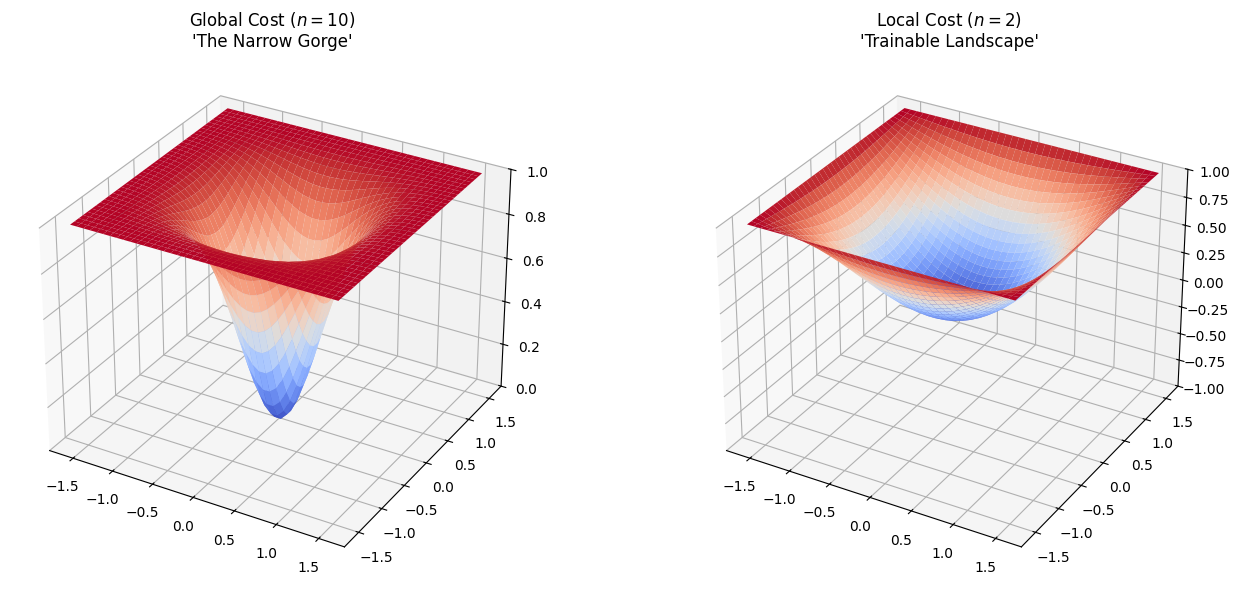

In [4]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def reproduce_landscape_fig_2():
    # Setup
    n_global = 10  # Many qubits for global BP
    n_local = 2    # Few qubits for local trainability
    res = 40       # Resolution of the grid
    
    x = np.linspace(-np.pi/2, np.pi/2, res)
    y = np.linspace(-np.pi/2, np.pi/2, res)
    X, Y = np.meshgrid(x, y)

    def get_landscape(n_qubits, mode="global"):
        dev = qml.device("default.qubit", wires=n_qubits)
        
        @qml.qnode(dev)
        def circuit(phi1, phi2):
            # Simple Ansatz
            for i in range(n_qubits):
                qml.RX(phi1, wires=i)
            for i in range(n_qubits):
                qml.RY(phi2, wires=i)

            if mode == "global":
                # Measure |00...0><00...0|
                return qml.probs(wires=range(n_qubits))
            else:
                # Measure local observable (1/n * sum Z_i)
                return qml.expval(qml.PauliZ(0))

        Z = np.zeros((res, res))
        for i in range(res):
            for j in range(res):
                val = circuit(x[i], y[j])
                # If global, take the probability of the |0...0> state
                Z[i, j] = val[0] if mode == "global" else val
        return Z

    # Generate data
    print("Generating Global Cost landscape (10 qubits)...")
    Z_global = 1 - get_landscape(n_global, mode="global")
    
    print("Generating Local Cost landscape (2 qubits)...")
    Z_local = 1 - get_landscape(n_local, mode="local")

    # Plotting
    fig = plt.figure(figsize=(14, 6))

    # Global Cost Plot
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Z_global, cmap=cm.coolwarm, antialiased=True)
    ax1.set_title(f"Global Cost ($n={n_global}$)\n'The Narrow Gorge'")
    ax1.set_zlim(0, 1)

    # Local Cost Plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z_local, cmap=cm.coolwarm, antialiased=True)
    ax2.set_title(f"Local Cost ($n={n_local}$)\n'Trainable Landscape'")
    ax2.set_zlim(-1, 1)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    reproduce_landscape_fig_2()

## Change the cost function to our tilted loss

Here we plot the 2D optimization landscape in a way similar to the tutorial, except for the change of loss function.

Since we focus on the regime when tilting parameter is negative, we define the loss function by 
$$ \mathcal{L}_\gamma(O,\rho(\bm{\theta})) := - \frac{1}{\gamma} \log \text{tr} \!\left( e^{- \gamma O} \rho(\bm{\theta}) \right),$$
so as to make gamma positive. If we consider the 1D optimization landscape with the toy model and with single parameter $\phi\in[-\pi, \pi]$, we have the cost function given by
$$\mathcal{L}_\gamma(O_G,\rho(\bm{\theta}))= - \frac{1}{\gamma}  \log\left(1 + (e^{-\gamma}-1)\left(1-\cos^{2n}\!\left(\frac{\phi}{2}\right) \right)\right).$$
Then the optimization landscape is plotted as below.

## Case 1: 1D small tilting parameter $\gamma = 0.1$.

<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\p'
C:\Users\fff\AppData\Local\Temp\ipykernel_1448\1822725605.py:39: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
C:\Users\fff\AppData\Local\Temp\ipykernel_1448\1822725605.py:42: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$\phi$')


Computing Original and Tilted Loss landscape for n=1...
Computing Original and Tilted Loss landscape for n=2...
Computing Original and Tilted Loss landscape for n=3...
Computing Original and Tilted Loss landscape for n=4...
Computing Original and Tilted Loss landscape for n=5...
Computing Original and Tilted Loss landscape for n=6...
Computing Original and Tilted Loss landscape for n=7...
Computing Original and Tilted Loss landscape for n=8...
Computing Original and Tilted Loss landscape for n=9...
Computing Original and Tilted Loss landscape for n=10...
Computing Original and Tilted Loss landscape for n=11...
Computing Original and Tilted Loss landscape for n=12...
Computing Original and Tilted Loss landscape for n=13...
Computing Original and Tilted Loss landscape for n=14...
Computing Original and Tilted Loss landscape for n=15...
Computing Original and Tilted Loss landscape for n=16...
Computing Original and Tilted Loss landscape for n=17...
Computing Original and Tilted Loss lands

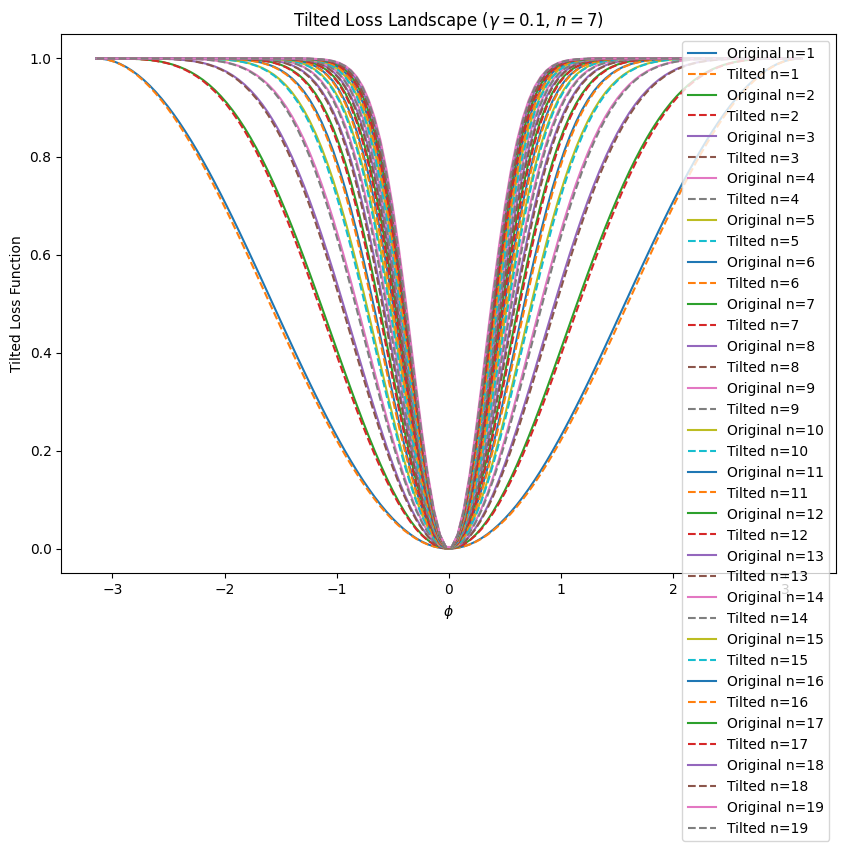

In [32]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import random
from matplotlib import cm


gamma = 0.1  # Tilting parameter
res = 120
N = 20

def tilted_loss(phi, n_qubits):
    return (1/(-gamma)) * np.log(1 + (np.exp(-gamma) - 1) * (1 - (np.cos(phi / 2) ** (2*n_qubits))))

def original_loss(phi, n_qubits):
    return 1 - (np.cos(phi / 2) ** (2*n_qubits))

# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
Z_original = [np.zeros(res) for _ in range(N)]
Z_tilted = [np.zeros(res) for _ in range(N)]


for n in range(1, N):
    for i in range(res):
        Z_original[n][i] = original_loss(x[i], n)
        Z_tilted[n][i] = tilted_loss(x[i], n)
    print(f"Computing Original and Tilted Loss landscape for n={n}...")


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot()
for n in range(1, N):
    ax.plot(x, Z_original[n], linestyle='-', label='Original n='+str(n))
    ax.plot(x, Z_tilted[n], linestyle='--', label='Tilted n='+str(n))

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
ax.legend()

ax.set_xlabel('$\phi$')
ax.set_ylabel('Tilted Loss Function')
plt.show()

## Case 2: 1D large tilting parameter $\gamma = 20$.

<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\p'
C:\Users\fff\AppData\Local\Temp\ipykernel_1448\2639362283.py:39: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
C:\Users\fff\AppData\Local\Temp\ipykernel_1448\2639362283.py:42: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$\phi$')


Computing Original and Tilted Loss landscape for n=1...
Computing Original and Tilted Loss landscape for n=2...
Computing Original and Tilted Loss landscape for n=3...
Computing Original and Tilted Loss landscape for n=4...
Computing Original and Tilted Loss landscape for n=5...
Computing Original and Tilted Loss landscape for n=6...
Computing Original and Tilted Loss landscape for n=7...
Computing Original and Tilted Loss landscape for n=8...
Computing Original and Tilted Loss landscape for n=9...
Computing Original and Tilted Loss landscape for n=10...
Computing Original and Tilted Loss landscape for n=11...
Computing Original and Tilted Loss landscape for n=12...
Computing Original and Tilted Loss landscape for n=13...
Computing Original and Tilted Loss landscape for n=14...
Computing Original and Tilted Loss landscape for n=15...
Computing Original and Tilted Loss landscape for n=16...
Computing Original and Tilted Loss landscape for n=17...
Computing Original and Tilted Loss lands

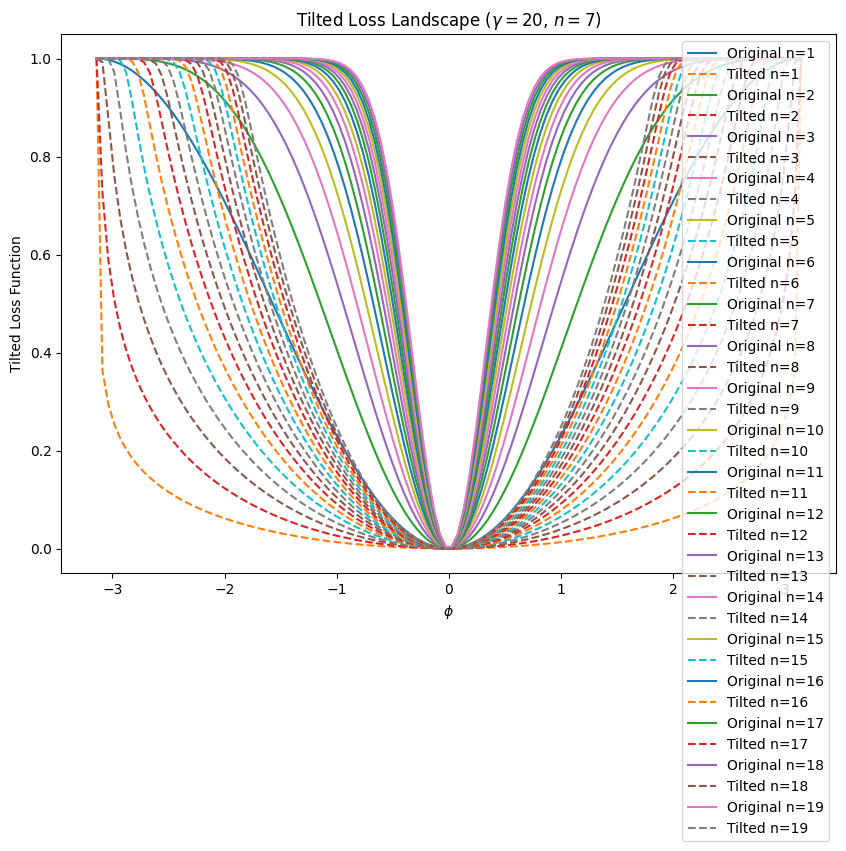

In [33]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import random
from matplotlib import cm


gamma = 20  # Tilting parameter
res = 120
N = 20

def tilted_loss(phi, n_qubits):
    return (1/(-gamma)) * np.log(1 + (np.exp(-gamma) - 1) * (1 - (np.cos(phi / 2) ** (2*n_qubits))))

def original_loss(phi, n_qubits):
    return 1 - (np.cos(phi / 2) ** (2*n_qubits))

# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
Z_original = [np.zeros(res) for _ in range(N)]
Z_tilted = [np.zeros(res) for _ in range(N)]


for n in range(1, N):
    for i in range(res):
        Z_original[n][i] = original_loss(x[i], n)
        Z_tilted[n][i] = tilted_loss(x[i], n)
    print(f"Computing Original and Tilted Loss landscape for n={n}...")


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot()
for n in range(1, N):
    ax.plot(x, Z_original[n], linestyle='-', label='Original n='+str(n))
    ax.plot(x, Z_tilted[n], linestyle='--', label='Tilted n='+str(n))

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
ax.legend()

ax.set_xlabel('$\phi$')
ax.set_ylabel('Tilted Loss Function')
plt.show()

## Case 3:  For 2D case, the loss function is changed.

qubit number = 10

(a) Original plot. (b) 2D small tilting parameter $\gamma = 0.1$. (c) 2D large tilting parameter $\gamma = 20$.

<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\g'
<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\g'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\g'
<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_33760\3842164636.py:51: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_xlabel('$\phi_1$')
C:\Users\fff\AppData\Local\Temp\ipykernel_337

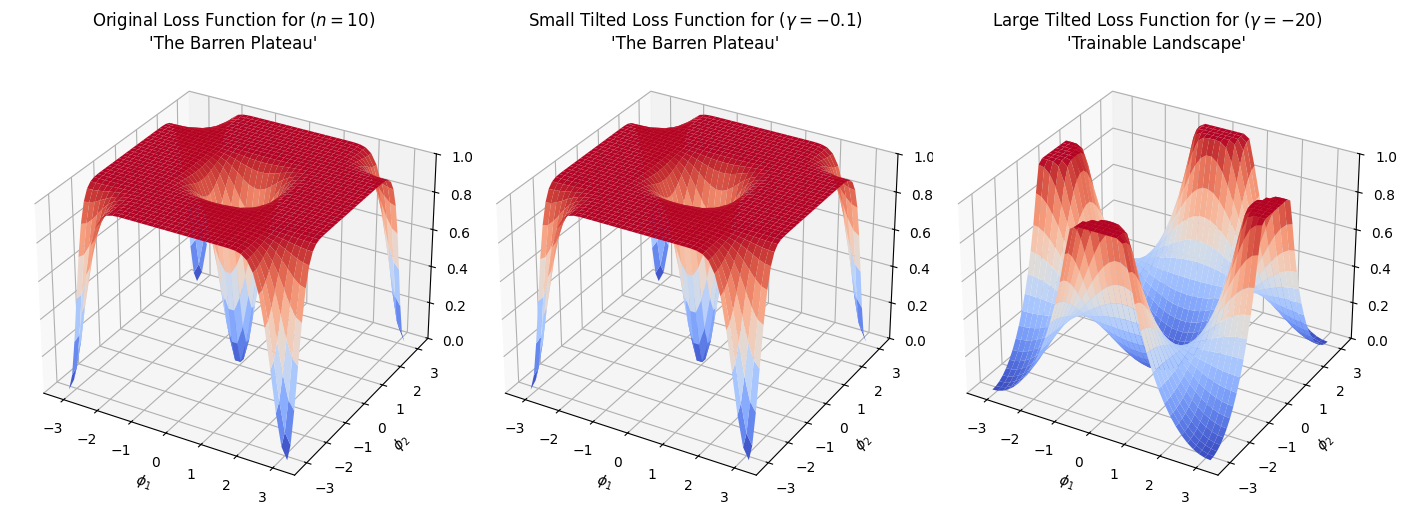

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib import cm

gamma_small = 0.1  # Small tilting parameter
gamma_large = 20  # Large tilting parameter
res = 40
n_qubits = 10
# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)

dev = qml.device("default.qubit", wires=n_qubits)

def get_landscape(gamma=None, mode='Orginal'):
    @qml.qnode(dev)
    def circuit(phi1, phi2):
        # Simple Ansatz
        for i in range(n_qubits):
            qml.RX(phi1, wires=i)
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        return qml.probs(wires=range(n_qubits))

    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            val = circuit(x[i], y[j])
            Z[i, j] = 1 - val[0] if mode == 'Orginal' else -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * (1 - val[0]))
    return Z

# print(f"Computing Tilted Loss landscape for n={n_qubits}...")
# for i in range(res):
#     for j in range(res):
#         Z[i, j] = calculate_tilted_loss(x[i], y[j])

Z_original = get_landscape()
Z_tilted_small = get_landscape(gamma_small, mode='Tilted')
Z_tilted_large = get_landscape(gamma_large, mode='Tilted')

# Plotting
fig = plt.figure(figsize=(14, 6))

# Original Cost Plot
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z_original, cmap=cm.coolwarm, antialiased=True)

ax1.set_xlabel('$\phi_1$')
ax1.set_ylabel('$\phi_2$')
ax1.set_title(f"Original Loss Function for ($n={n_qubits}$)\n'The Barren Plateau'")
ax1.set_zlim(0, 1)

# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_tilted_small, cmap=cm.coolwarm, antialiased=True)
ax2.set_xlabel('$\phi_1$')
ax2.set_ylabel('$\phi_2$')
ax2.set_title(f"Small Tilted Loss Function for ($\gamma={-gamma_small}$)\n'The Barren Plateau'")
ax2.set_zlim(0, 1)

# Tilted Cost Plot, large gamma
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z_tilted_large, cmap=cm.coolwarm, antialiased=True)
ax3.set_xlabel('$\phi_1$')
ax3.set_ylabel('$\phi_2$')
ax3.set_title(f"Large Tilted Loss Function for ($\gamma={-gamma_large}$)\n'Trainable Landscape'")
ax3.set_zlim(0, 1)

plt.tight_layout()
plt.show()



If we only focus on the range between $[-0.9\pi, 0.9\pi]$, so as to exclude those boundary minimas. We have

<>:56: SyntaxWarning: invalid escape sequence '\g'
<>:61: SyntaxWarning: invalid escape sequence '\g'
<>:56: SyntaxWarning: invalid escape sequence '\g'
<>:61: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_33760\2851279984.py:56: SyntaxWarning: invalid escape sequence '\g'
  ax2.set_title(f"Small Tilted Loss Function for ($\gamma={gamma_small}$)\n'Trainable Landscape'")
C:\Users\fff\AppData\Local\Temp\ipykernel_33760\2851279984.py:61: SyntaxWarning: invalid escape sequence '\g'
  ax3.set_title(f"Large Tilted Loss Function for ($\gamma={gamma_large}$)\n'Trainable Landscape'")


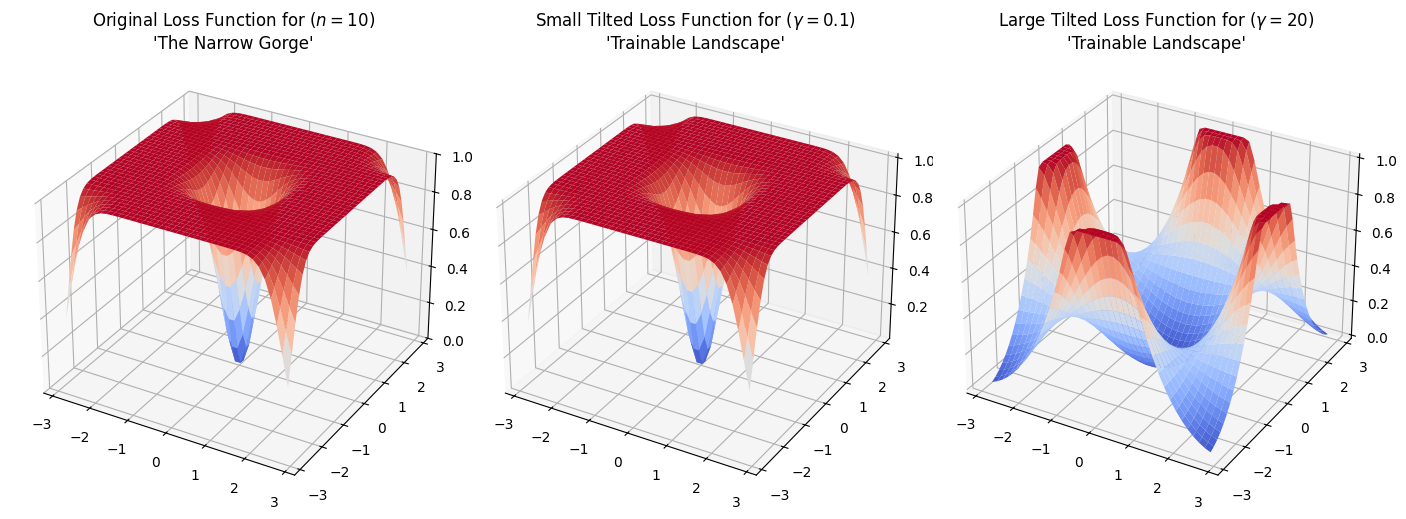

In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib import cm

gamma_small = 0.1  # Small tilting parameter
gamma_large = 20  # Large tilting parameter
res = 40
n_qubits = 10
# Grid for plotting
x = np.linspace(-0.9*np.pi, 0.9*np.pi, res)
y = np.linspace(-0.9*np.pi, 0.9*np.pi, res)
X, Y = np.meshgrid(x, y)

dev = qml.device("default.qubit", wires=n_qubits)

def get_landscape(gamma=None, mode='Orginal'):
    @qml.qnode(dev)
    def circuit(phi1, phi2):
        # Simple Ansatz
        for i in range(n_qubits):
            qml.RX(phi1, wires=i)
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        return qml.probs(wires=range(n_qubits))

    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            val = circuit(x[i], y[j])
            Z[i, j] = 1 - val[0] if mode == 'Orginal' else -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * (1-val[0]))
    return Z

# print(f"Computing Tilted Loss landscape for n={n_qubits}...")
# for i in range(res):
#     for j in range(res):
#         Z[i, j] = calculate_tilted_loss(x[i], y[j])

Z_original = get_landscape()
Z_tilted_small = get_landscape(gamma_small, mode='Tilted')
Z_tilted_large = get_landscape(gamma_large, mode='Tilted')

# Plotting
fig = plt.figure(figsize=(14, 6))

# Original Cost Plot
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z_original, cmap=cm.coolwarm, antialiased=True)
ax1.set_title(f"Original Loss Function for ($n={n_qubits}$)\n'The Narrow Gorge'")
ax1.set_zlim(0, 1)

# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_tilted_small, cmap=cm.coolwarm, antialiased=True)
ax2.set_title(f"Small Tilted Loss Function for ($\gamma={gamma_small}$)\n'Trainable Landscape'")

# Tilted Cost Plot, large gamma
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z_tilted_large, cmap=cm.coolwarm, antialiased=True)
ax3.set_title(f"Large Tilted Loss Function for ($\gamma={gamma_large}$)\n'Trainable Landscape'")

plt.tight_layout()
plt.show()



In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib import cm

res = 40
# Grid for plotting
x = np.linspace(-0.9*np.pi, 0.9*np.pi, res)
y = np.linspace(-0.9*np.pi, 0.9*np.pi, res)
X, Y = np.meshgrid(x, y)


def get_landscape(n_qubits, gamma=None, mode='Orginal'):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev)
    def circuit(phi1, phi2):
        # Simple Ansatz
        for i in range(n_qubits):
            qml.RX(phi1, wires=i)
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        return qml.probs(wires=range(n_qubits))

    Z = np.zeros((res, res))
    for i in range(res):
        for j in range(res):
            val = circuit(x[i], y[j])
            Z[i, j] = 1 - val[0] if mode == 'Orginal' else -(1/gamma) * np.log(1 + (np.exp(-gamma) - 1) * (1-val[0]))
    return Z

# Calculate the original landscape with different qubits
Qubits = [2, 10, 20]
Z_original = []
for q in Qubits:
    Z_original.append(get_landscape(q))

# Calculate the tilted loss landscape with different gammas
Gammas = [0.1, 10, 20]
Z_tilted = []
n_qubits = 20
for gamma in Gammas:
    Z_tilted.append(get_landscape(n_qubits, gamma, mode='Tilted'))

# Plotting
fig = plt.figure(figsize=(14, 6))

# Original Cost Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
for i in range(len(Qubits)):
    q = Qubits[i]
    Z = Z_original[i]
    surf = ax1.plot_surface(X, Y, Z, cmap=cm.coolwarm, antialiased=True)
# ax1.set_title(f"Original Loss Function for ($n={n_qubits}$)\n'The Narrow Gorge'")
ax1.set_zlim(0, 1)

# Tilted Cost Plot, small gamma
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for i in range(len(Qubits)):
    q = Qubits[i]
    Z = Z_tilted[i]
    surf = ax2.plot_surface(X, Y, Z, cmap=cm.coolwarm, antialiased=True)
# ax2.set_title(f"Tilted Loss Function for ($\gamma={gamma_small}$)\n'Trainable Landscape'")
ax1.set_zlim(0, 1)

plt.tight_layout()
plt.show()



## plot the 2D figure for different qubit number 

<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:32: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_18004\1272555842.py:32: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
C:\Users\fff\AppData\Local\Temp\ipykernel_18004\1272555842.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = tilted_loss(x[i], y[j])


Computing Tilted Loss landscape for n=20...


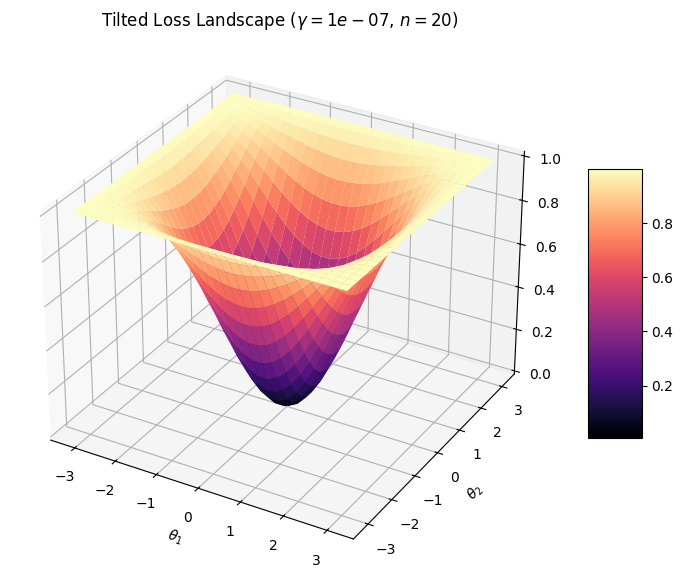

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 0.1  # Tilting parameter

res = 30
n_qubits = 20

def tilted_loss(phi1, phi2):
    return (1/(-gamma) * np.log(1 + (expm(-gamma) - 1) * (1 - (np.cos(phi1 / 2) ** 2) * (np.cos(phi2 / 2) ** 2))))


# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)
Z = np.zeros((res, res))

print(f"Computing Tilted Loss landscape for n={n_qubits}...")
for i in range(res):
    for j in range(res):

        Z[i, j] = tilted_loss(x[i], y[j])


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
ax.set_xlabel('$\\theta_1$')
ax.set_ylabel('$\\theta_2$')
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

large tilting parameter gamma=60, Here by focusing on the angles between [-pi, pi], we have

<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:32: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\709581474.py:32: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\709581474.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = tilted_loss(x[i], y[j])


Computing Tilted Loss landscape for n=10...


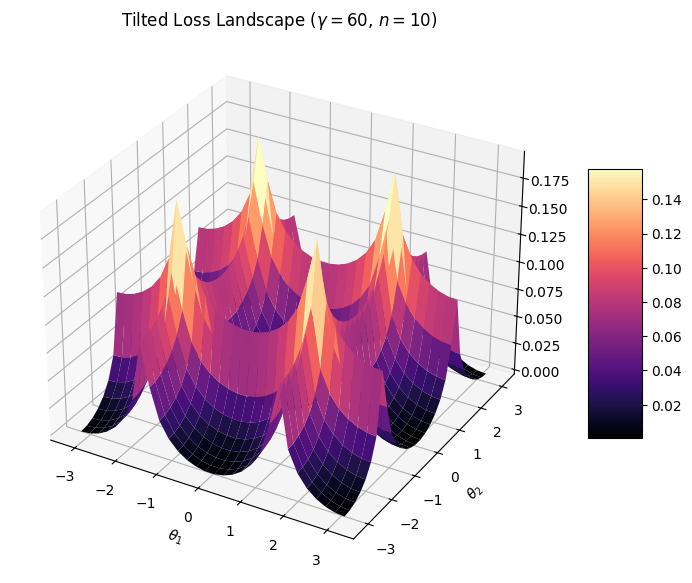

In [22]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 60  # Tilting parameter
res = 30
n_qubits = 10

def tilted_loss(phi1, phi2):
    return (1/(-gamma) * np.log(1 + (expm(-gamma) - 1) * (1 - (np.cos(phi1) ** 2) * (np.cos(phi2) ** 2))))


# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)
Z = np.zeros((res, res))

print(f"Computing Tilted Loss landscape for n={n_qubits}...")
for i in range(res):
    for j in range(res):

        Z[i, j] = tilted_loss(x[i], y[j])


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
ax.set_xlabel('$\\theta_1$')
ax.set_ylabel('$\\theta_2$')
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

large tilting parameter gamma=60, Here by focusing on the angles between [-0.9*pi, 0.9*pi], we have

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\3057966686.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=10...


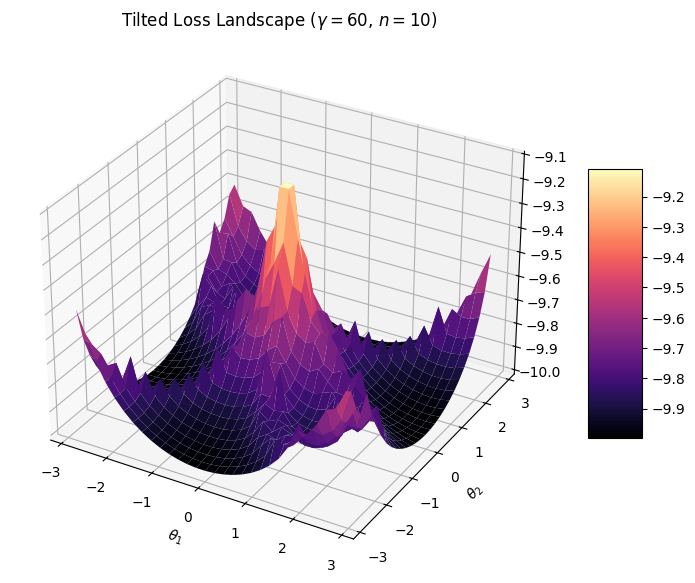

In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 60  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 10
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi * 0.9, np.pi * 0.9, res)
    y = np.linspace(-np.pi * 0.9, np.pi * 0.9, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

Here by focusing on the angles between [-pi/2, pi/2], we have

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\715994001.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=10...


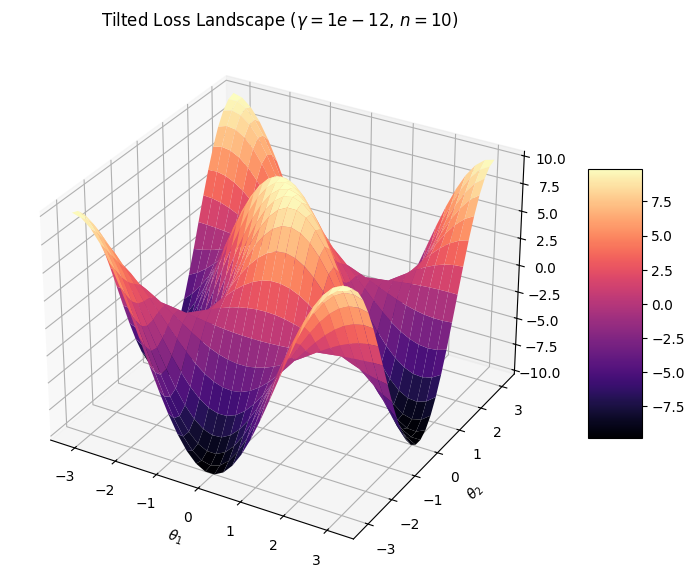

In [7]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 0.000000000001  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 10
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_7148\658582743.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=6...


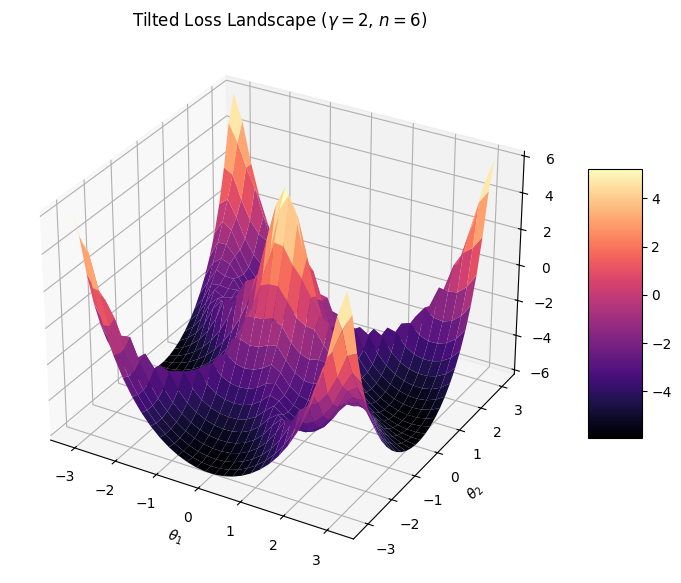

In [8]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 2  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 6
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_7148\2817439296.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=6...


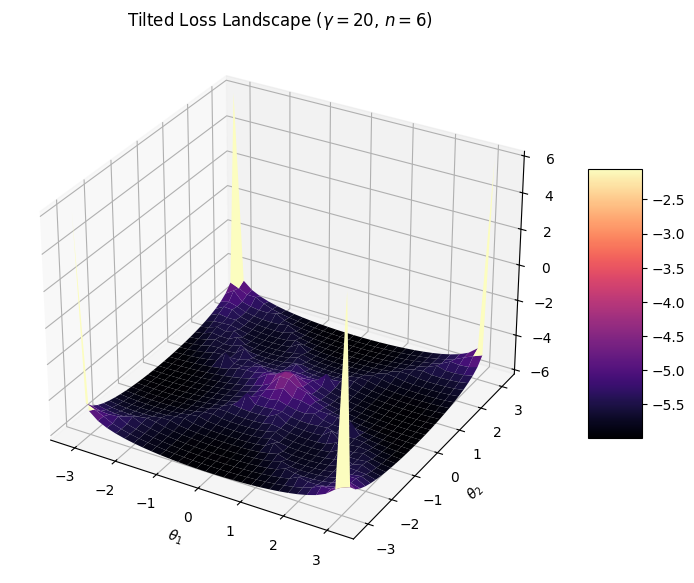

In [9]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 20  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 6
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()